<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/Age_Gender_Fairness_Aware_and_Uncertainty_Quantified_Ensemble_Models_for_Personalized_Heart_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Import Libraries & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,
                           confusion_matrix, roc_curve, precision_recall_curve)
import xgboost as xgb
import lightgbm as lgb
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore')

# ----------------- Load Dataset -----------------
df = pd.read_csv('/content/drive/MyDrive/Dataset/heart_disease_risk_dataset_earlymed.csv')  # Change path

print(df.shape)
print(df['Heart_Risk'].value_counts(normalize=True))
print("\nGender Distribution:")
print(df['Gender'].value_counts())
print("\nAge Statistics:")
print(df['Age'].describe())

(70000, 19)
Heart_Risk
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64

Gender Distribution:
Gender
1.0    38425
0.0    31575
Name: count, dtype: int64

Age Statistics:
count    70000.000000
mean        54.461986
std         16.410794
min         20.000000
25%         45.000000
50%         56.000000
75%         67.000000
max         84.000000
Name: Age, dtype: float64


In [5]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/heart_disease_risk_dataset_earlymed.csv')
print(df.shape)
print(df.columns.tolist())

(70000, 19)
['Chest_Pain', 'Shortness_of_Breath', 'Fatigue', 'Palpitations', 'Dizziness', 'Swelling', 'Pain_Arms_Jaw_Back', 'Cold_Sweats_Nausea', 'High_BP', 'High_Cholesterol', 'Diabetes', 'Smoking', 'Obesity', 'Sedentary_Lifestyle', 'Family_History', 'Chronic_Stress', 'Gender', 'Age', 'Heart_Risk']


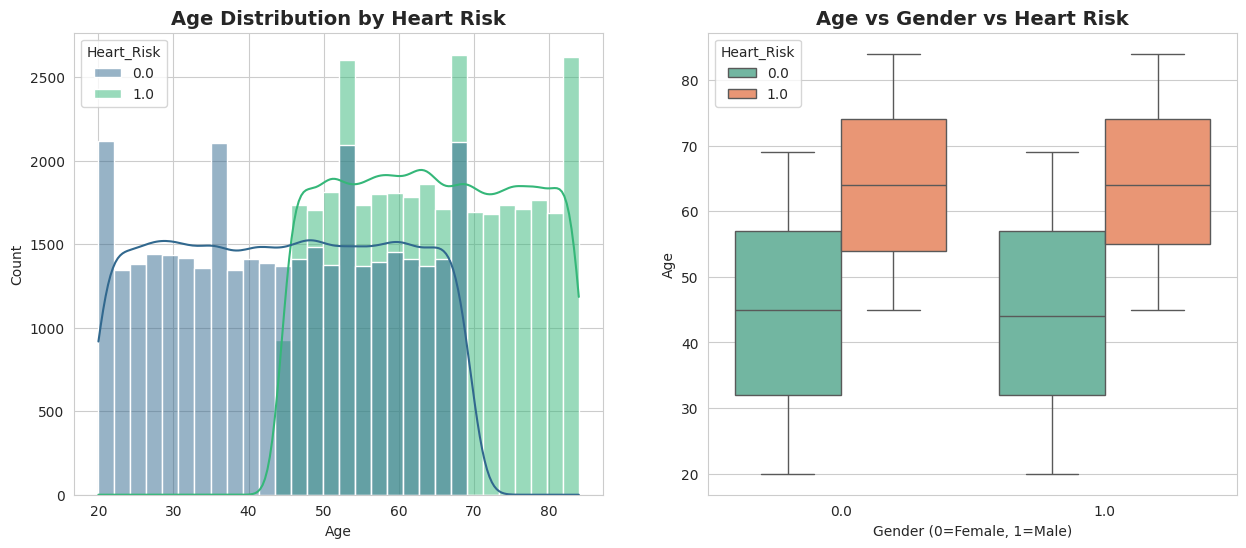

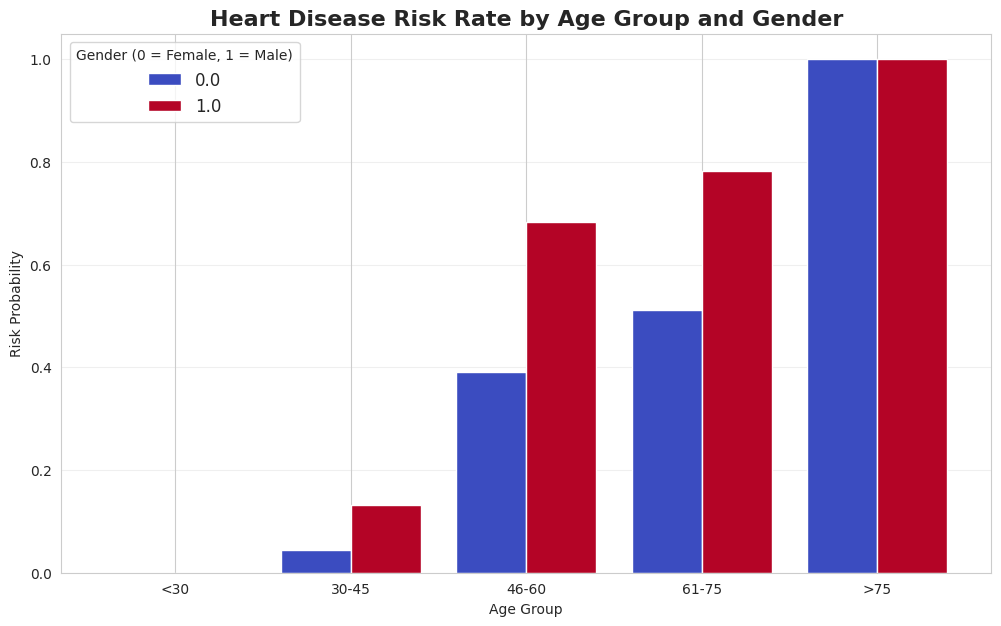

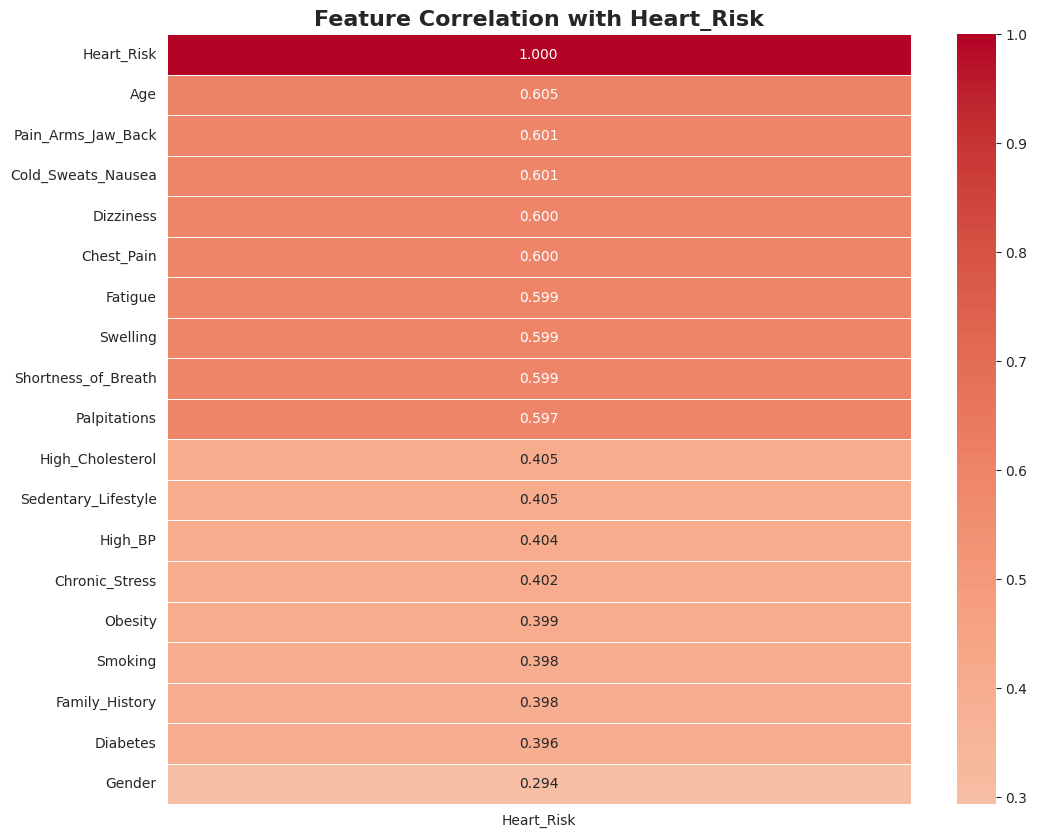

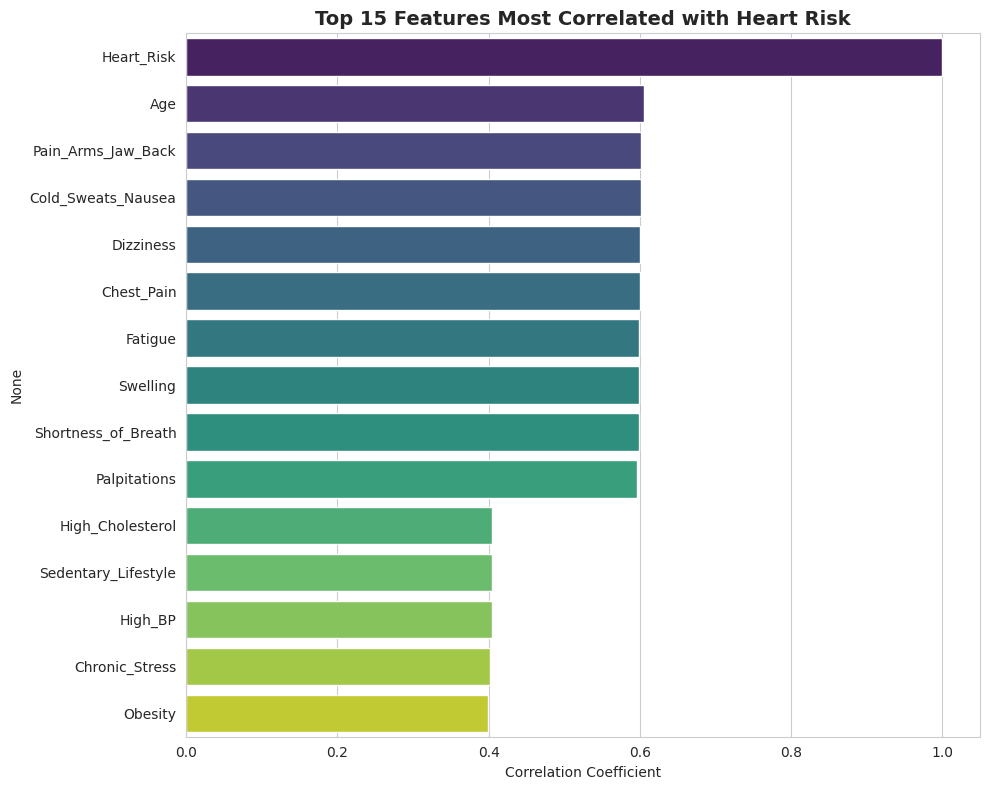

In [6]:
#Exploratory Data Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# ====================== CORRECTED EDA (Step 2) ======================

# 1. Age Distribution by Heart Risk
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Age', hue='Heart_Risk', bins=30, kde=True, palette='viridis')
plt.title('Age Distribution by Heart Risk', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Gender', y='Age', hue='Heart_Risk', palette='Set2')
plt.title('Age vs Gender vs Heart Risk', fontsize=14, fontweight='bold')
plt.xlabel('Gender (0=Female, 1=Male)')
plt.show()

# 2. Risk Rate by Age Group and Gender (Key Fairness Visualization)
df['Age_Group'] = pd.cut(df['Age'],
                         bins=[0, 30, 45, 60, 75, 100],
                         labels=['<30', '30-45', '46-60', '61-75', '>75'])

risk_by_group = df.groupby(['Age_Group', 'Gender'])['Heart_Risk'].mean().unstack()

risk_by_group.plot(kind='bar', figsize=(12, 7), colormap='coolwarm', width=0.8)
plt.title('Heart Disease Risk Rate by Age Group and Gender', fontsize=16, fontweight='bold')
plt.ylabel('Risk Probability')
plt.xlabel('Age Group')
plt.legend(title='Gender (0 = Female, 1 = Male)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.show()

# 3. Correlation Heatmap - FIXED
plt.figure(figsize=(12, 10))

numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

target_corr = corr[['Heart_Risk']].sort_values(by='Heart_Risk', ascending=False)

sns.heatmap(target_corr,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.3f',
            linewidths=0.5)
plt.title('Feature Correlation with Heart_Risk', fontsize=16, fontweight='bold')
plt.show()

# 4. Top Features Bar Plot
plt.figure(figsize=(10, 8))
top_features = target_corr.head(15)
sns.barplot(x=top_features['Heart_Risk'], y=top_features.index, palette='viridis')
plt.title('Top 15 Features Most Correlated with Heart Risk', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [7]:
# Features and Target
X = df.drop(['Heart_Risk', 'Age_Group'], axis=1)   # Remove target and categorical group
y = df['Heart_Risk']

from sklearn.model_selection import train_test_split

# Stratified split (important for imbalanced medical data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y, shuffle=True
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Class distribution in train:\n", y_train.value_counts(normalize=True))

Training shape: (52500, 18)
Test shape: (17500, 18)
Class distribution in train:
 Heart_Risk
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


In [8]:
#Build Fairness-Aware + Uncertainty-Quantified Ensemble

import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Base Models
rf = RandomForestClassifier(n_estimators=400, max_depth=12, random_state=42, n_jobs=-1)
xgb_model = xgb.XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=8,
                              random_state=42, eval_metric='auc')
lgb_model = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, max_depth=8,
                               random_state=42, verbose=-1)

# Soft Voting Ensemble
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb_model), ('lgb', lgb_model)],
    voting='soft'
)

# Calibrated Ensemble → Better Uncertainty & Probability Calibration
calibrated_ensemble = CalibratedClassifierCV(ensemble, cv=5, method='isotonic')

print("Training Ensemble Model...")
calibrated_ensemble.fit(X_train, y_train)

Training Ensemble Model...


CalibratedClassifierCV(cv=5,
                       estimator=VotingClassifier(estimators=[('rf',
                                                               RandomForestClassifier(max_depth=12,
                                                                                      n_estimators=400,
                                                                                      n_jobs=-1,
                                                                                      random_state=42)),
                                                              ('xgb',
                                                               XGBClassifier(base_score=None,
                                                                             booster=None,
                                                                             callbacks=None,
                                                                             colsample_bylevel=None,
                                                                             colsample_bynode=None,
                                                                             colsample_bytree=None,
                                                                             device=None,
                                                                             early_stopping_rounds=None,
                                                                             enable_categorical=False,...
                                                                             max_cat_threshold=None,
                                                                             max_cat_to_onehot=None,
                                                                             max_delta_step=None,
                                                                             max_depth=8,
                                                                             max_leaves=None,
                                                                             min_child_weight=None,
                                                                             missing=nan,
                                                                             monotone_constraints=None,
                                                                             multi_strategy=None,
                                                                             n_estimators=400,
                                                                             n_jobs=None,
                                                                             num_parallel_tree=None, ...)),
                                                              ('lgb',
                                                               LGBMClassifier(learning_rate=0.05,
                                                                              max_depth=8,
                                                                              n_estimators=400,
                                                                              random_state=42,
                                                                              verbose=-1))],
                                                  voting='soft'),
                       method='isotonic')

In [9]:
#Prediction & Performance Metrics
y_pred = calibrated_ensemble.predict(X_test)
y_prob = calibrated_ensemble.predict_proba(X_test)[:, 1]

print("=== Model Performance ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

=== Model Performance ===
Accuracy : 0.9929714285714286
ROC-AUC  : 0.9995517714285714

Classification Report:

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      8750
         1.0       0.99      0.99      0.99      8750

    accuracy                           0.99     17500
   macro avg       0.99      0.99      0.99     17500
weighted avg       0.99      0.99      0.99     17500



In [10]:
#Fairness Analysis (Age & Gender)
def fairness_analysis(X_test, y_test, y_prob, sensitive_col):
    X_test = X_test.copy()
    X_test['pred_prob'] = y_prob
    X_test['true'] = y_test.values
    X_test['pred'] = (y_prob >= 0.5).astype(int)

    results = {}
    for name, group in X_test.groupby(sensitive_col):
        results[name] = {
            'Count': len(group),
            'Accuracy': accuracy_score(group['true'], group['pred']),
            'ROC_AUC': roc_auc_score(group['true'], group['pred_prob']),
            'Mean_Pred_Prob': group['pred_prob'].mean(),
            'Positive_Rate': group['pred'].mean()
        }
    return pd.DataFrame(results).round(4).T

# 1. Fairness by Gender
print("=== FAIRNESS BY GENDER ===")
print(fairness_analysis(X_test, y_test, y_prob, 'Gender'))

# 2. Fairness by Age Group
X_test_age = X_test.copy()
X_test_age['Age_Group'] = pd.cut(X_test_age['Age'],
                                 bins=[0, 30, 45, 60, 75, 100],
                                 labels=['<30','30-45','46-60','61-75','>75'])

print("\n=== FAIRNESS BY AGE GROUP ===")
print(fairness_analysis(X_test_age, y_test, y_prob, 'Age_Group'))

=== FAIRNESS BY GENDER ===
      Count  Accuracy  ROC_AUC  Mean_Pred_Prob  Positive_Rate
0.0  7926.0    0.9939   0.9994          0.3459         0.3441
1.0  9574.0    0.9922   0.9996          0.6267         0.6269

=== FAIRNESS BY AGE GROUP ===
        Count  Accuracy  ROC_AUC  Mean_Pred_Prob  Positive_Rate
<30    1978.0    1.0000      NaN          0.0006         0.0000
30-45  2852.0    0.9972   0.9999          0.0831         0.0820
46-60  5874.0    0.9871   0.9990          0.5535         0.5528
61-75  4893.0    0.9920   0.9992          0.6847         0.6836
>75    1903.0    1.0000      NaN          0.9992         1.0000


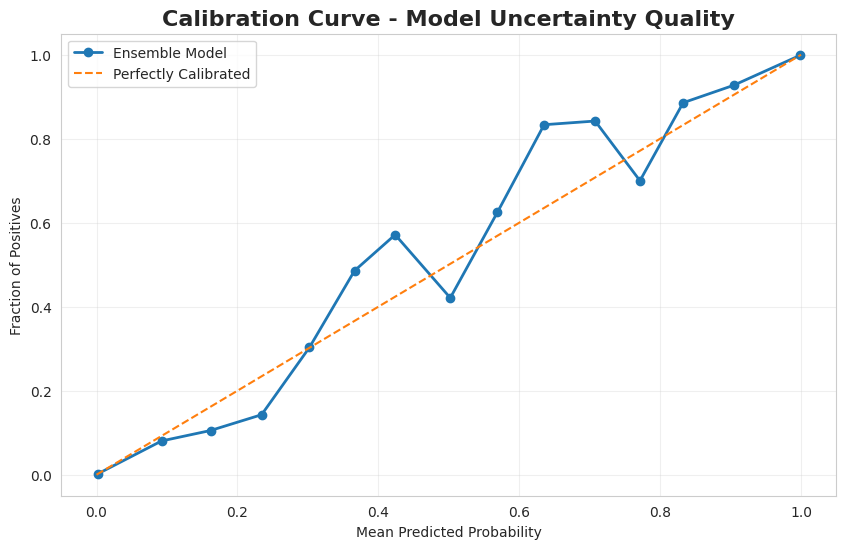

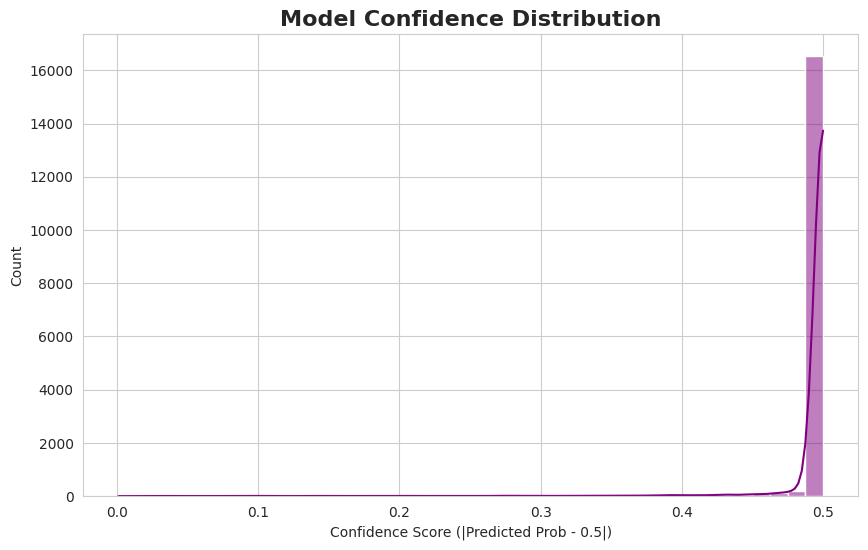

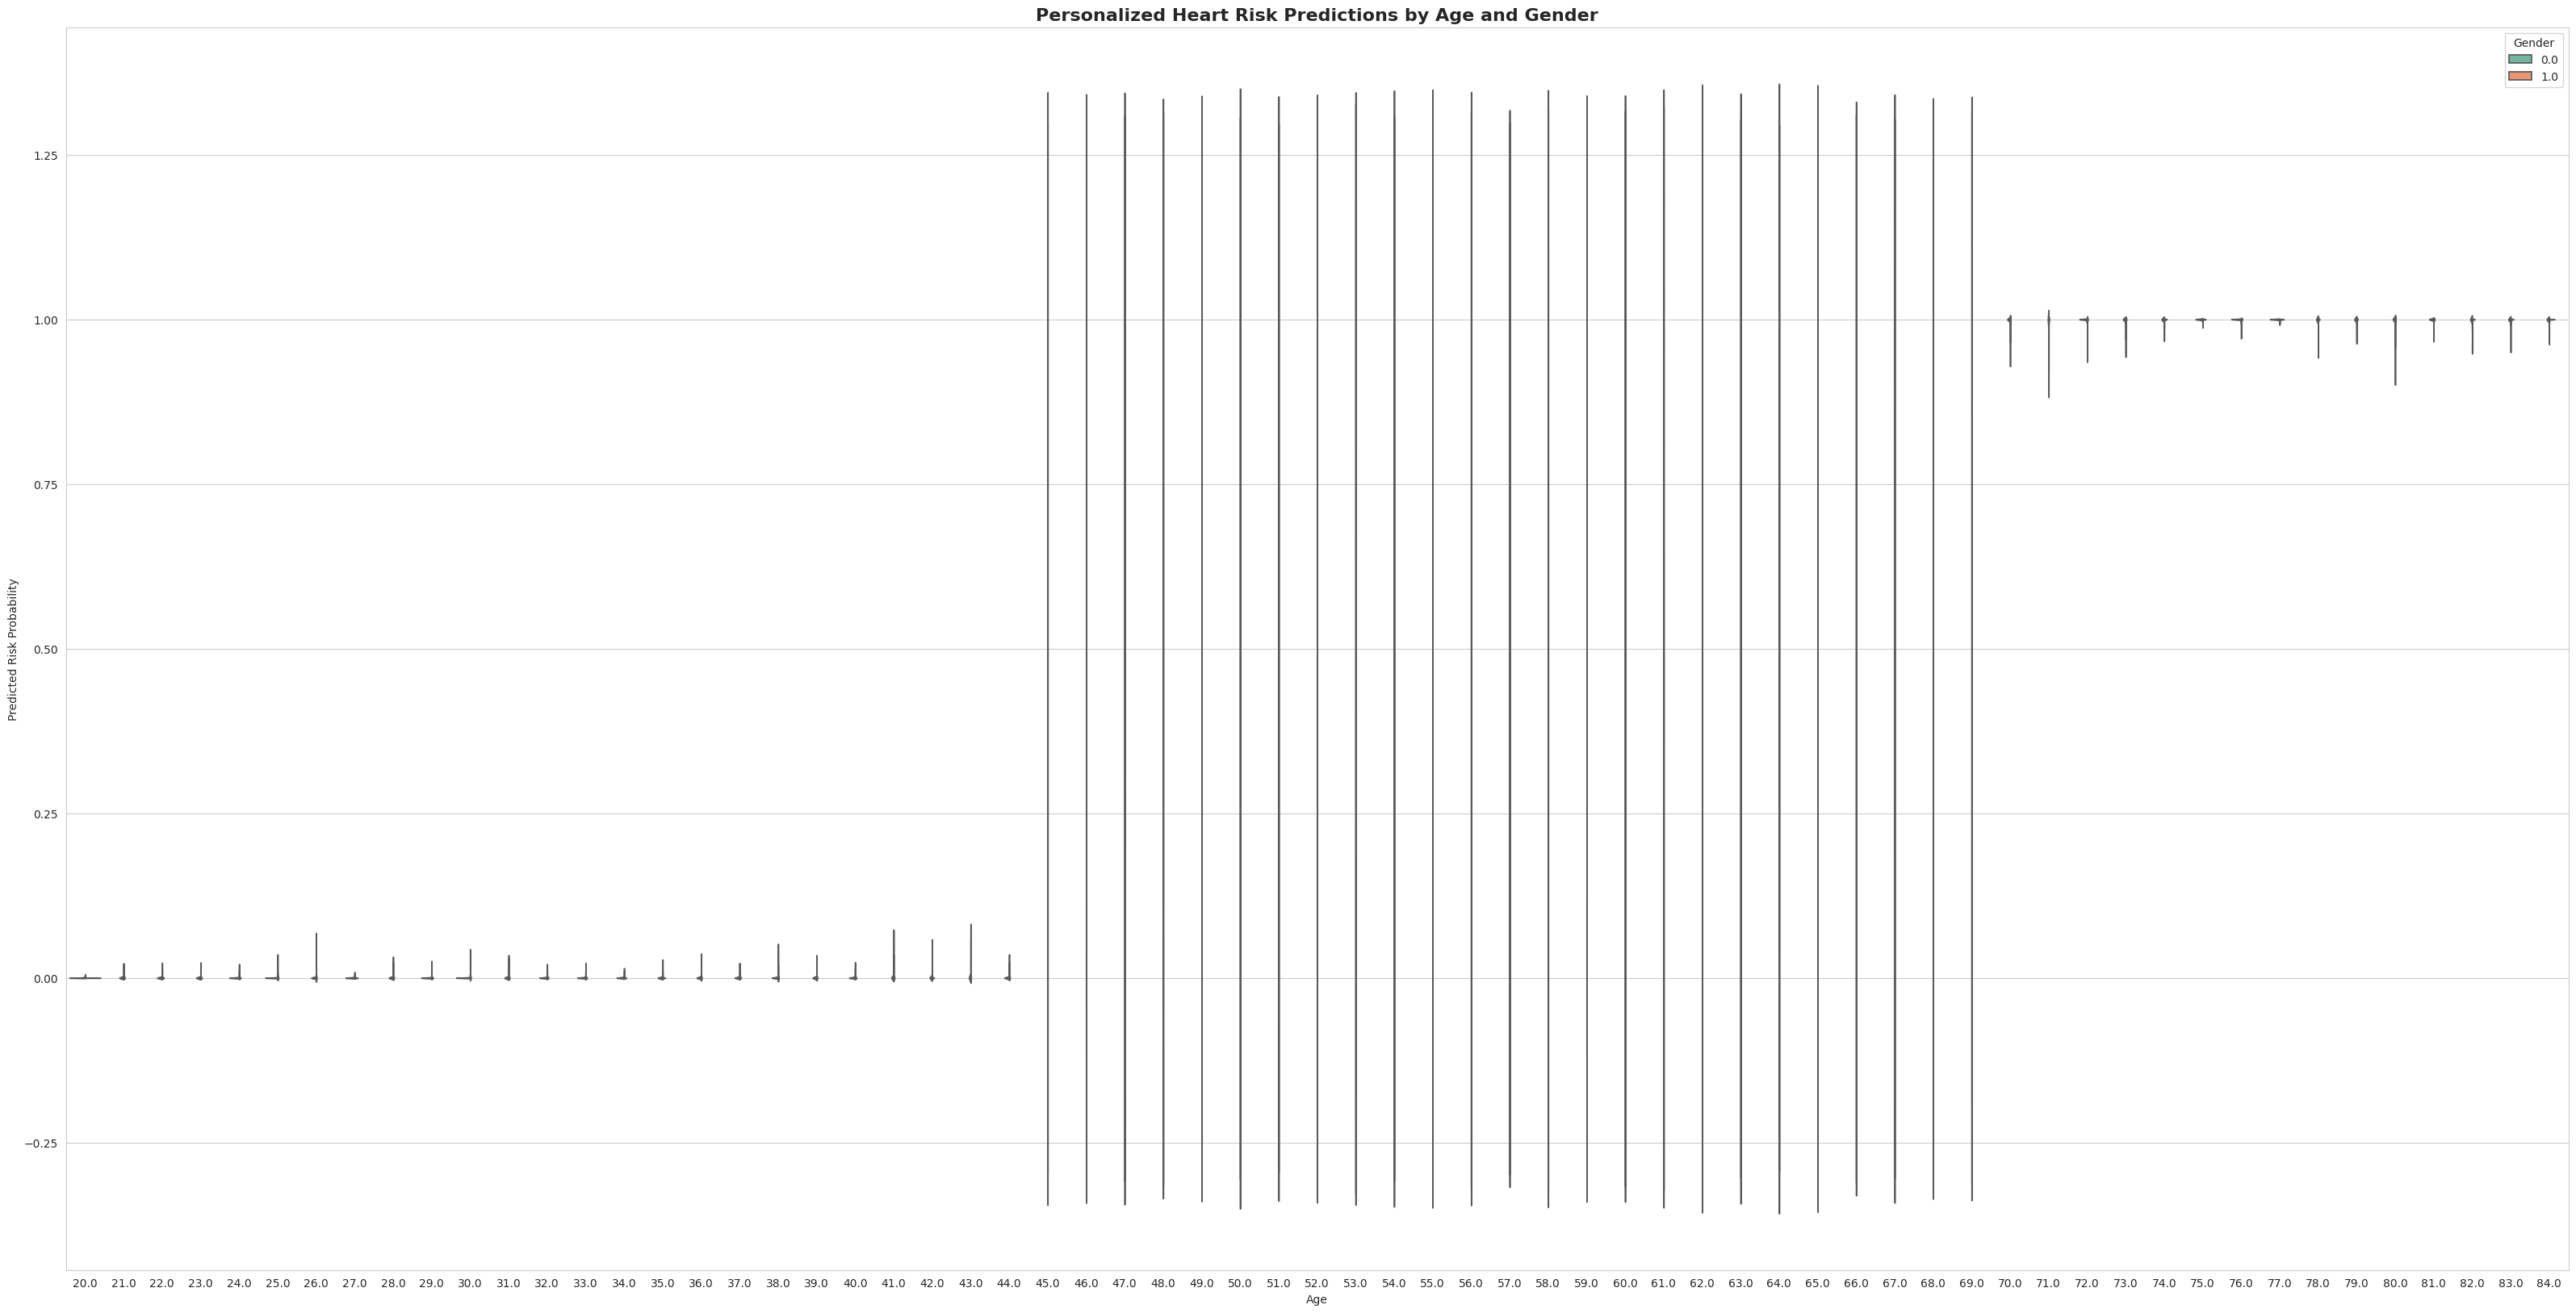

In [18]:
#Uncertainty & Calibration Visualization
from sklearn.calibration import calibration_curve

# 1. Calibration Curve
plt.figure(figsize=(10, 6))
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=15)
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Ensemble Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.title('Calibration Curve - Model Uncertainty Quality', fontsize=16, fontweight='bold')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Confidence Distribution
confidence = np.abs(y_prob - 0.5)

plt.figure(figsize=(10, 6))
sns.histplot(confidence, bins=40, kde=True, color='purple')
plt.title('Model Confidence Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Confidence Score (|Predicted Prob - 0.5|)')
plt.ylabel('Count')
plt.show()

# 3. Personalized Risk by Age & Gender
plt.figure(figsize=(40,20))
sns.violinplot(x='Age', y=y_prob, hue='Gender', data=X_test.assign(Gender=X_test['Gender']),
               split=True, inner='quart', palette='Set2')
plt.title('Personalized Heart Risk Predictions by Age and Gender', fontsize=16, fontweight='bold')
plt.ylabel('Predicted Risk Probability')
plt.show()

=== TOP 15 COMBINED FEATURE IMPORTANCE (RF + XGBoost Average) ===
                Feature  Combined_Importance  Importance_RF  Importance_XGB
0    Pain_Arms_Jaw_Back              0.26625        0.14490         0.38759
1                   Age              0.11569        0.13915         0.09223
2               Fatigue              0.10230        0.10285         0.10174
3            Chest_Pain              0.10008        0.10876         0.09139
4    Cold_Sweats_Nausea              0.08520        0.10449         0.06590
5              Swelling              0.07357        0.09709         0.05005
6   Shortness_of_Breath              0.06427        0.08158         0.04695
7          Palpitations              0.06031        0.06790         0.05272
8             Dizziness              0.05699        0.07011         0.04388
9      High_Cholesterol              0.01041        0.01260         0.00822
10  Sedentary_Lifestyle              0.01008        0.01125         0.00892
11       Chronic_Stres

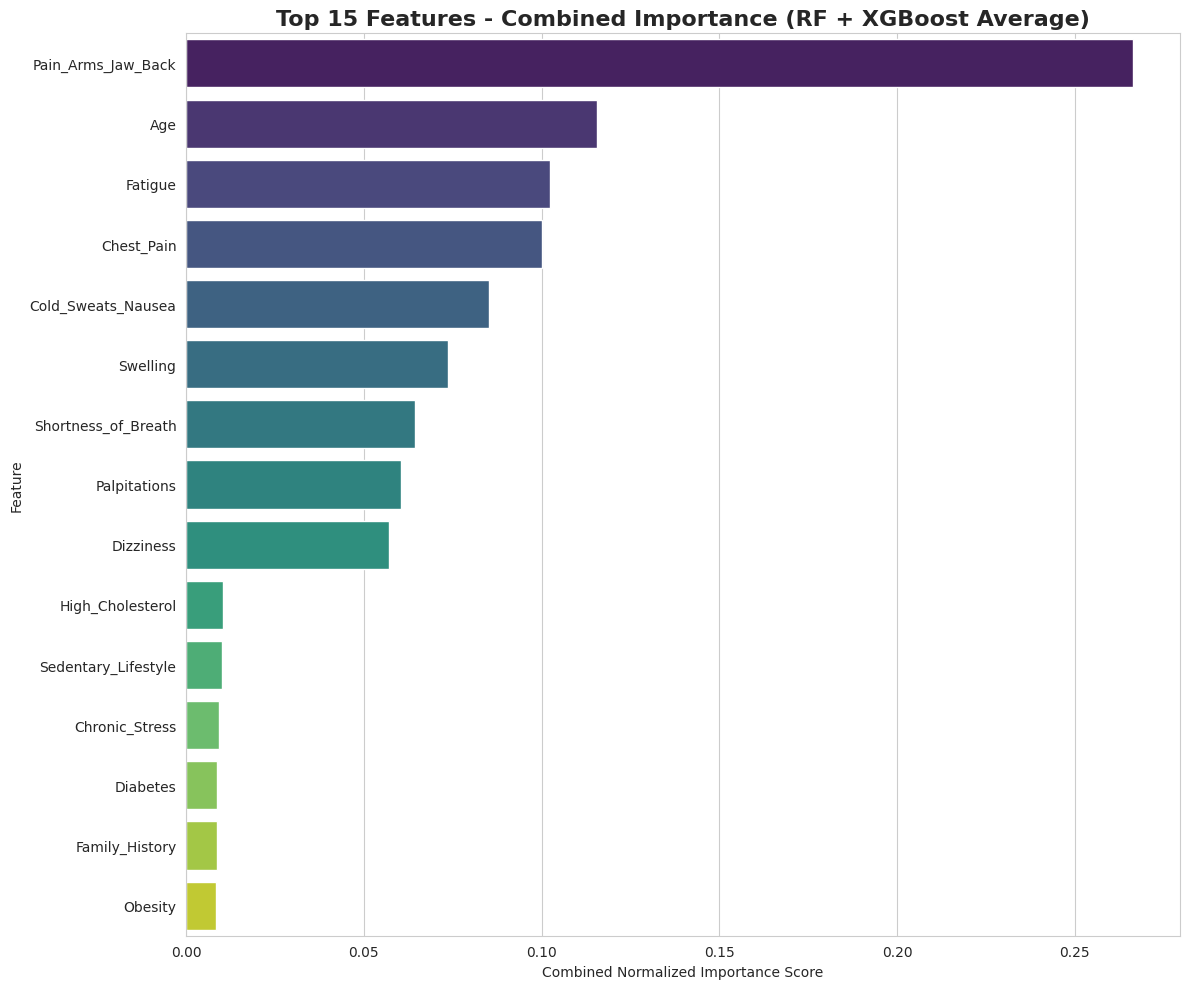

In [28]:
# ====================== COMBINED FEATURE IMPORTANCE (RF + XGB) ======================

# Extract models from the calibrated ensemble
voting_clf = calibrated_ensemble.calibrated_classifiers_[0].estimator

rf_model = voting_clf.named_estimators_['rf']
xgb_model = voting_clf.named_estimators_['xgb']

# Get importance scores
rf_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance_RF': rf_model.feature_importances_
})

xgb_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance_XGB': xgb_model.feature_importances_
})

# Merge and calculate average rank/score
combined = rf_imp.merge(xgb_imp, on='Feature')

# Normalize both importances to same scale (optional but good)
combined['Importance_RF'] = combined['Importance_RF'] / combined['Importance_RF'].sum()
combined['Importance_XGB'] = combined['Importance_XGB'] / combined['Importance_XGB'].sum()

# Combined Score (Average)
combined['Combined_Importance'] = (combined['Importance_RF'] + combined['Importance_XGB']) / 2

# Final Ranking
combined = combined.sort_values('Combined_Importance', ascending=False).reset_index(drop=True)

# Display Top 15
print("=== TOP 15 COMBINED FEATURE IMPORTANCE (RF + XGBoost Average) ===")
print(combined[['Feature', 'Combined_Importance', 'Importance_RF', 'Importance_XGB']].head(15).round(5))

# ====================== PLOT ======================
plt.figure(figsize=(12, 10))
sns.barplot(x='Combined_Importance', y='Feature', data=combined.head(15), palette='viridis')
plt.title('Top 15 Features - Combined Importance (RF + XGBoost Average)',
          fontsize=16, fontweight='bold')
plt.xlabel('Combined Normalized Importance Score')
plt.tight_layout()
plt.show()

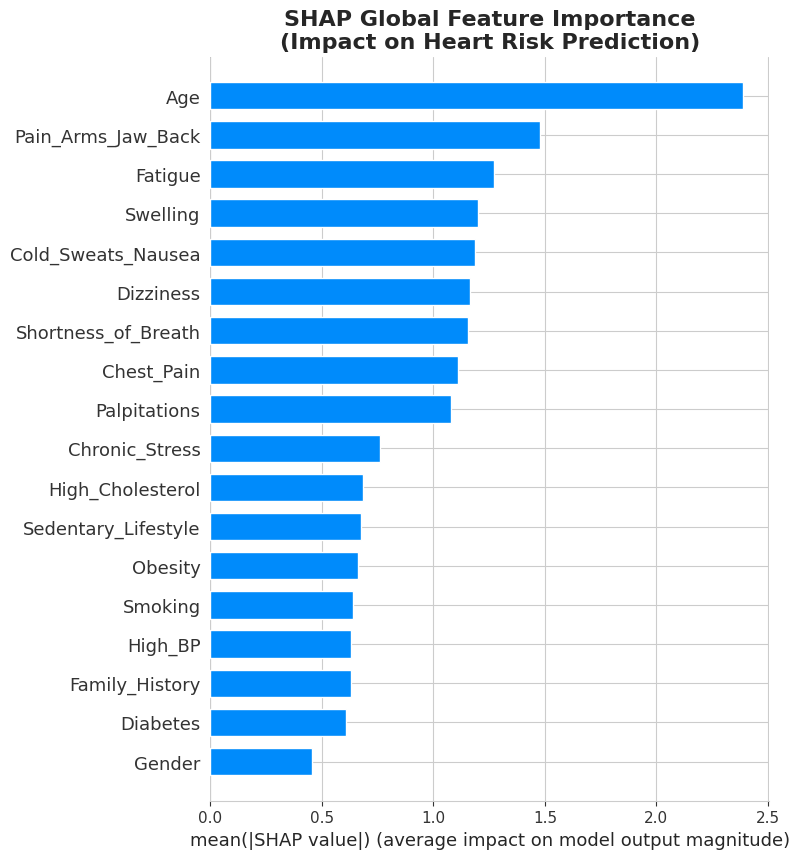

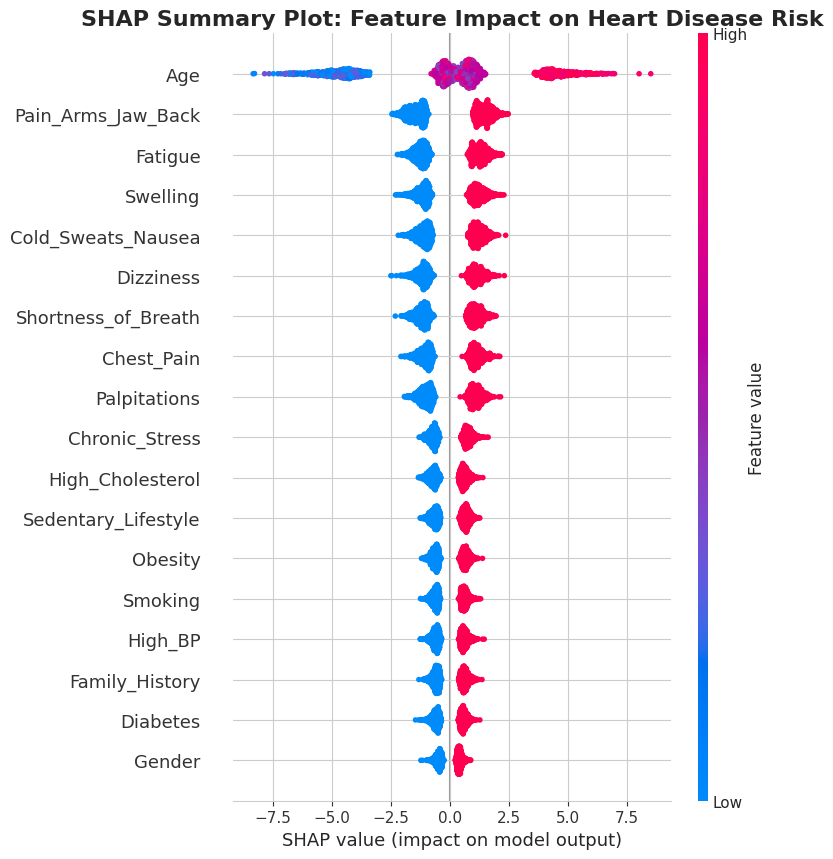

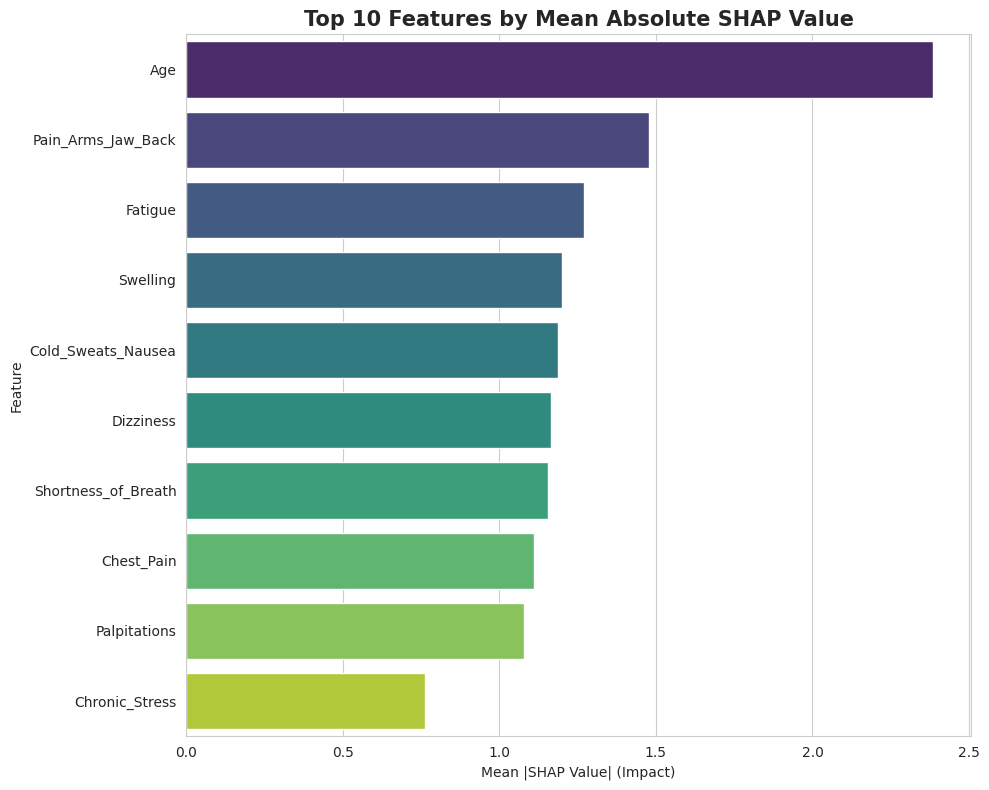

In [31]:
import shap
import matplotlib.pyplot as plt

# Extract the best performing model (XGBoost or RF)
voting_clf = calibrated_ensemble.calibrated_classifiers_[0].estimator
xgb_model = voting_clf.named_estimators_['xgb']   # Best for SHAP usually

# Create SHAP Explainer
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values (use sample for speed + clarity)
np.random.seed(42)
X_sample = X_test.sample(2000, random_state=42)   # Adjust size if needed
shap_values = explainer.shap_values(X_sample)

# ========================== Q1 PAPER PLOTS ==========================

# 1. Global Feature Importance (Bar Plot)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance\n(Impact on Heart Risk Prediction)",
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. SHAP Summary Plot (Beeswarm) - Most Important for Papers
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Summary Plot: Feature Impact on Heart Disease Risk",
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Top 10 Features Impact (Clean Bar)
shap_importance = pd.DataFrame({
    'Feature': X_sample.columns,
    'SHAP_Importance': np.abs(shap_values).mean(0)
}).sort_values('SHAP_Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='SHAP_Importance', y='Feature', data=shap_importance.head(10), palette='viridis')
plt.title('Top 10 Features by Mean Absolute SHAP Value', fontsize=15, fontweight='bold')
plt.xlabel('Mean |SHAP Value| (Impact)')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

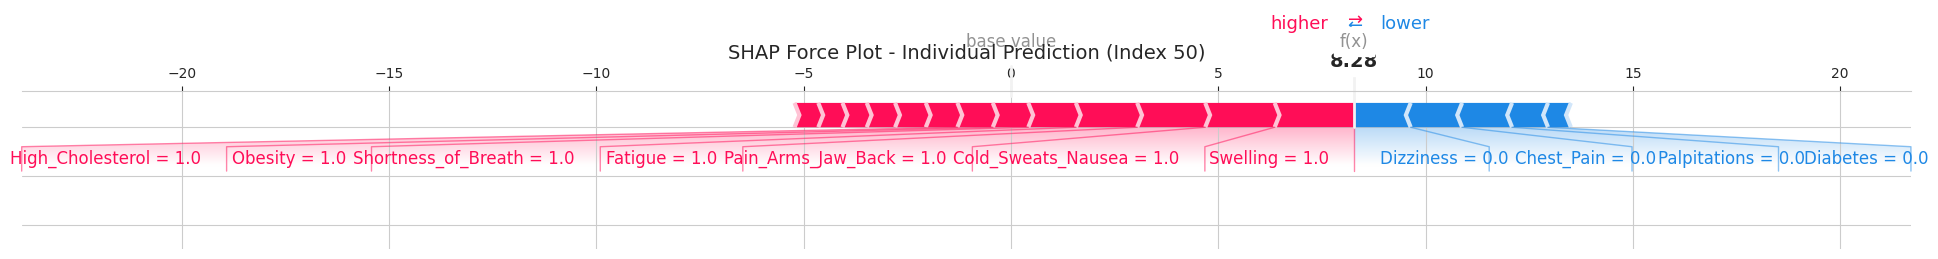

In [32]:
# Individual explanation example
idx = 50  # You can change this

plt.figure(figsize=(10, 6))
shap.force_plot(explainer.expected_value,
                shap_values[idx],
                X_sample.iloc[idx],
                matplotlib=True,
                show=False)
plt.title(f"SHAP Force Plot - Individual Prediction (Index {idx})", fontsize=14)
plt.tight_layout()
plt.show()